In [ ]:
# Task 1 - Data Preparation

import pandas as pd
from sklearn.preprocessing import StandardScaler

#Load data
df = pd.read_csv('D:\BA\BITSoM BA Assignment Datasets\ml-assessment-nishant-saxena\data\q2_customers.csv')
#Features
X= df.copy()
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#covert back to Dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()


<>:5: SyntaxWarning: invalid escape sequence '\B'
<>:5: SyntaxWarning: invalid escape sequence '\B'
C:\Users\nisha\AppData\Local\Temp\ipykernel_63820\2828136508.py:5: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv('D:\BA\BITSoM BA Assignment Datasets\ml-assessment-nishant-saxena\data\q2_customers.csv')


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


K-means clustering is based on  distance (Euclidean distance). Feature with larger scales features (example, annual_spend) can dominate smaller scale features (example, visits_per_month), leading to biased clusters.
StandardScalar normalizes all features to have mean = 0 and variance = 1, ensuring each feature contributes equally to the clustering process. 

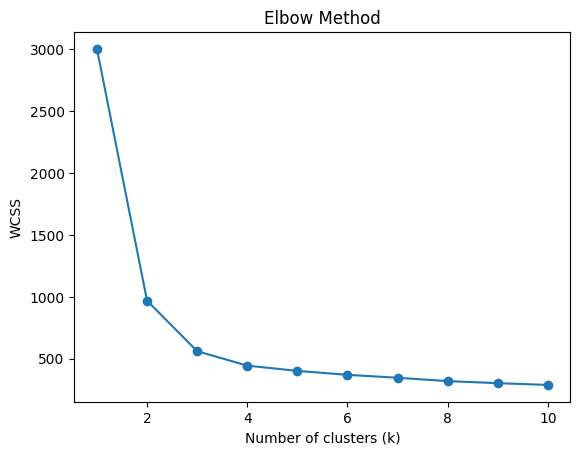

In [ ]:
# Task 2 - Choosing K — Elbow Method 

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

#Polt
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()



The elbow point appears at K=3, where the rate of decrease in WCSS slows down significantly.
This indicates that adding more clusters beyond this point doesn't significantly improve cluster compactness.
Therefore, k=3 is chosen as the optimal number of clusters.

In [ ]:
# Task 3 - K-Means Clustering
#Fit KMeans with k=3

k=3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

#Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns= df.columns[:-1] #exclude cluster column
)
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


- Cluster 0: Younger customers with low spending but frequent visits- likely budget-conscious regular buyers.
- Cluster 1: High spenders with large basket size- premium customers contributing significant revenue.
- Cluster 2: Infrequent visitors with long gap since last visit- potentially churn risk customers.

In [11]:
#Task 4 - Dimensionality Reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

#Loadings
loadings= pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
loadings

Explained variance ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 has high positive weights for annual_spend and bucket_size, indicating it represents customer spending power. 
PC2 is influenced by visits_per_month and days_since_last_widget, capturing customer engagement and activity level.
Thus, PCA reduces the dataset into dimensions representing spending behavior and customer activity

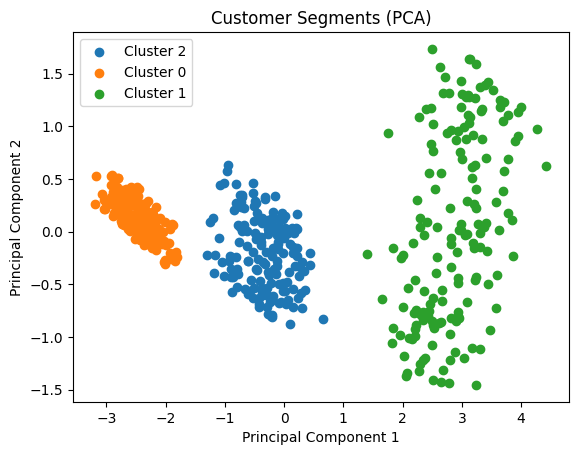

In [12]:
#Task 5 Cluster Visualization
plt.figure()
for cluster in df['cluster'].unique():
    plt.scatter(
        X_pca[df['cluster'] == cluster, 0],
        X_pca[df['cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()